# Gaussian Process Regression (GPR) for Battery Cycle-Life Prediction

- Train: `batch1.mat`
- Test: `batch2.mat`
- Goal: 초기 100사이클 시계열 패턴으로 `cycle_life` 예측

베이지안 MCMC가 오래 걸릴 때, 소표본(셀 수 적음)에서 GPR은 강력한 대안이다.


In [ ]:
# 필요 패키지 (필요 시)
# !pip install mat73 scikit-learn matplotlib pandas numpy



In [19]:
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mat73
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.CRITICAL)
np.random.seed(42)

DATA_DIR = Path('/Users/ryopxd/workspace/data/archive')
BATCH1_PATH = DATA_DIR / 'batch1.mat'
BATCH2_PATH = DATA_DIR / 'batch2.mat'



## 1) 데이터 로드 / 전처리 함수

- batch를 list-of-dict로 통일
- 초기 100사이클 추출
- 점프 이상치(`|ΔQD|>0.05`) + 범위 이상치(`QD<0.85 or >1.15`) 제거
- 제거 후 길이가 줄어도 100포인트로 보간하여 시계열 길이 고정


In [20]:
def load_batch_cells(path):
    data = mat73.loadmat(str(path))
    batch = data['batch']
    if isinstance(batch, dict):
        keys = list(batch.keys())
        n = len(batch[keys[0]])
        cells = [{k: batch[k][i] for k in keys} for i in range(n)]
    else:
        cells = batch
    return cells


def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def preprocess_first100(cell, jump_thr=0.05, qd_min=0.85, qd_max=1.15):
    """초기 100사이클 summary 시계열 전처리 + 길이 고정(100)"""
    s = cell.get('summary', {})
    if not isinstance(s, dict):
        return None

    qd = np.asarray(s.get('QDischarge', []), dtype=float)
    ir = np.asarray(s.get('IR', []), dtype=float)
    tavg = np.asarray(s.get('Tavg', []), dtype=float)
    ct = np.asarray(s.get('chargetime', []), dtype=float)

    n = min(len(qd), len(ir), len(tavg), len(ct), 100)
    if n < 30:
        return None

    qd = qd[:n]
    ir = ir[:n]
    tavg = tavg[:n]
    ct = ct[:n]
    cyc = np.arange(1, n + 1, dtype=float)

    # 공통 유효값
    mask_base = np.isfinite(qd) & np.isfinite(ir) & np.isfinite(tavg) & np.isfinite(ct)

    # QD jump + range 이상치
    dq = np.abs(np.diff(qd, prepend=qd[0]))
    mask_jump = dq <= jump_thr
    mask_range = (qd >= qd_min) & (qd <= qd_max)

    mask = mask_base & mask_jump & mask_range

    qd, ir, tavg, ct, cyc = qd[mask], ir[mask], tavg[mask], ct[mask], cyc[mask]
    if len(qd) < 30:
        return None

    # 길이 100으로 재보간 (시계열 길이 고정)
    target_cyc = np.arange(1, 101, dtype=float)
    qd_100 = np.interp(target_cyc, cyc, qd)
    ir_100 = np.interp(target_cyc, cyc, ir)
    t_100 = np.interp(target_cyc, cyc, tavg)
    ct_100 = np.interp(target_cyc, cyc, ct)

    return {
        'cycle': target_cyc,
        'QD': qd_100,
        'IR': ir_100,
        'Tavg': t_100,
        'chargetime': ct_100,
        'n_total_raw': int(n),
        'n_used_after_filter': int(len(qd)),
    }



## 2) 학습/테스트 테이블 생성

- 셀별로 초기 100사이클 시계열을 flatten하여 feature 벡터 구성
- target은 `cycle_life`
- batch2는 `cycle_life` 결측 셀 제외 후 평가


In [21]:
def build_dataset(cells, split_name):
    rows = []
    for cid, cell in enumerate(cells):
        rec = preprocess_first100(cell)
        if rec is None:
            continue

        y = safe_float(cell.get('cycle_life', np.nan))

        # 시계열 flatten feature (QD/IR/Tavg/chargetime)
        feat = np.concatenate([
            rec['QD'],
            rec['IR'],
            rec['Tavg'],
            rec['chargetime']
        ])

        row = {
            'global_id': f'{split_name}_{cid}',
            'split': split_name,
            'cell_id': cid,
            'cycle_life': y,
            'n_total_raw': rec['n_total_raw'],
            'n_used_after_filter': rec['n_used_after_filter'],
            'feature': feat,
        }
        rows.append(row)
    return pd.DataFrame(rows)

b1_cells = load_batch_cells(BATCH1_PATH)
b2_cells = load_batch_cells(BATCH2_PATH)

train_df = build_dataset(b1_cells, 'train')
test_df = build_dataset(b2_cells, 'test')

test_df_eval = test_df[test_df['cycle_life'].notna()].copy()

print('train cells:', len(train_df))
print('test cells :', len(test_df), '(known y:', len(test_df_eval), ')')

print('')
print('[filter summary]')
print('train removed mean:', (train_df['n_total_raw'] - train_df['n_used_after_filter']).mean().round(2))
print('test  removed mean:', (test_df['n_total_raw'] - test_df['n_used_after_filter']).mean().round(2))


train cells: 46
test cells : 47 (known y: 39 )

[filter summary]
train removed mean: 2.09
test  removed mean: 0.81


In [28]:
# numpy matrix로 변환
X_train = np.vstack(train_df['feature'].values)
X_test = np.vstack(test_df_eval['feature'].values)
y_train = train_df['cycle_life'].to_numpy(dtype=float)
y_test = test_df_eval['cycle_life'].to_numpy(dtype=float)

# 안정화를 위해 target log 변환
y_train_log = np.log(y_train)

print('X_train:', X_train.shape, 'X_test:', X_test.shape)



X_train: (46, 400) X_test: (39, 400)


## 3) 스케일링 + 차원축소(PCA)

시계열 flatten feature는 고차원(400차원)이므로, 소표본 안정화를 위해 PCA 적용


In [23]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# train 샘플 수를 고려한 보수적 차원축소
n_comp = min(15, X_train_s.shape[0] - 5, X_train_s.shape[1])
pca = PCA(n_components=n_comp, random_state=42)
X_train_p = pca.fit_transform(X_train_s)
X_test_p = pca.transform(X_test_s)

print('PCA components:', n_comp)
print('Explained variance ratio sum:', pca.explained_variance_ratio_.sum().round(4))



PCA components: 15
Explained variance ratio sum: 0.9991


## 4) GPR 학습 (batch1) / 예측 (batch2)


In [24]:
# 커널: 상수 * RBF + White noise
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))          + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e0))

gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=42,
)

gpr.fit(X_train_p, y_train_log)

# log-space 예측
y_pred_log, y_pred_log_std = gpr.predict(X_test_p, return_std=True)

# 역변환
y_pred = np.exp(y_pred_log)
# 대략적 90% 구간 (log-normal 근사)
y_pred_lo = np.exp(y_pred_log - 1.645 * y_pred_log_std)
y_pred_hi = np.exp(y_pred_log + 1.645 * y_pred_log_std)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('Optimized kernel:', gpr.kernel_)
print(f'RMSE: {rmse:.3f}')
print(f'MAPE: {mape:.3f}%')



Optimized kernel: 2.51**2 * RBF(length_scale=69.8) + WhiteKernel(noise_level=0.331)
RMSE: 333.121
MAPE: 64.268%


In [ ]:
pred_df = test_df_eval[['global_id', 'cell_id', 'cycle_life']].copy()
pred_df = pred_df.rename(columns={'cycle_life': 'y_true'})
pred_df['y_pred'] = y_pred
pred_df['y_pred_lo_5'] = y_pred_lo
pred_df['y_pred_hi_95'] = y_pred_hi
pred_df = pred_df.sort_values('y_true')
pred_df.head(10)

,global_id,cell_id,y_true,y_pred,y_pred_lo_5,y_pred_hi_95
19,test_19,19,392.0,797.787123,640.874074,993.119114
6,test_6,6,393.0,771.437706,613.276399,970.388124
15,test_15,15,396.0,702.686672,563.610010,876.081954
21,test_21,21,408.0,779.167472,599.531810,1012.626751
30,test_30,30,412.0,825.419200,331.643697,2054.363948
5,test_5,5,416.0,742.595156,576.461184,956.608322
2,test_2,2,424.0,674.335411,544.269215,835.484047
31,test_31,31,425.0,825.285415,649.142617,1049.224004
14,test_14,14,426.0,825.419126,331.643668,2054.363766
28,test_28,28,437.0,825.419380,331.643769,2054.364397


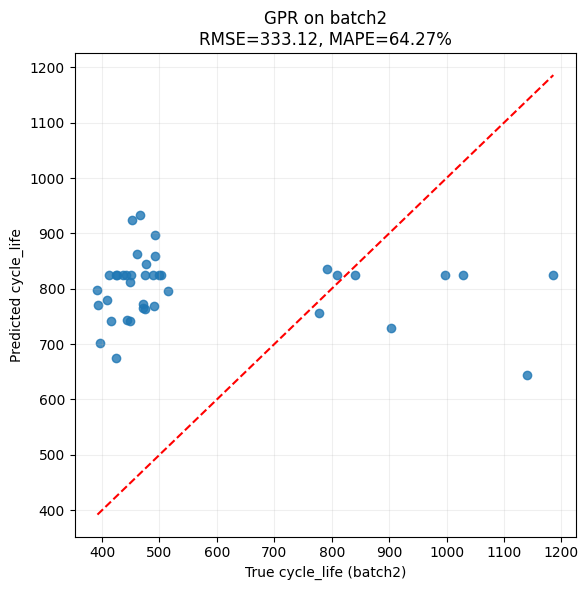

In [26]:
# 예측 성능 시각화
plt.figure(figsize=(6, 6))
plt.scatter(pred_df['y_true'], pred_df['y_pred'], alpha=0.8)
lo = min(pred_df['y_true'].min(), pred_df['y_pred'].min())
hi = max(pred_df['y_true'].max(), pred_df['y_pred'].max())
plt.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
plt.xlabel('True cycle_life (batch2)')
plt.ylabel('Predicted cycle_life')
plt.title(f'GPR on batch2\nRMSE={rmse:.2f}, MAPE={mape:.2f}%')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


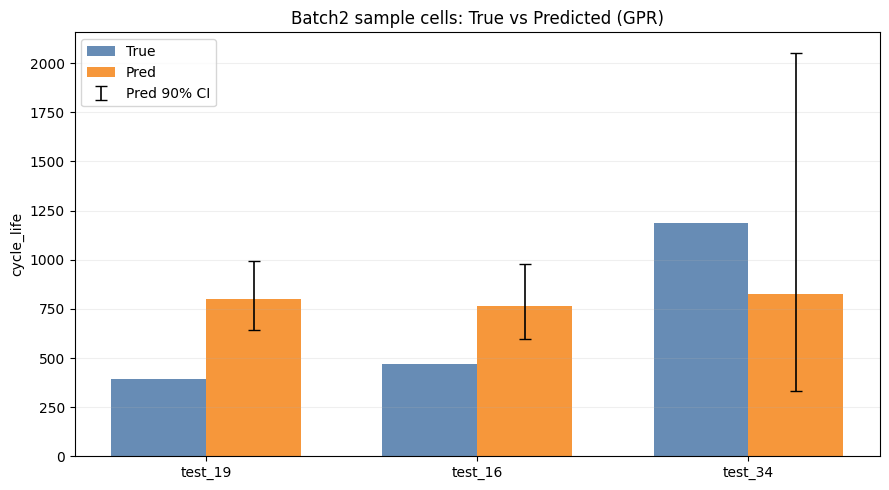

,global_id,y_true,y_pred,y_pred_lo_5,y_pred_hi_95
0,test_19,392.0,797.79,640.87,993.12
1,test_16,472.0,765.38,598.02,979.59
2,test_34,1186.0,825.42,331.64,2054.36


In [27]:
# 3개 셀 샘플 비교 (정답 vs 예측)
show_df = pred_df.iloc[[0, len(pred_df)//2, len(pred_df)-1]].copy() if len(pred_df) >= 3 else pred_df.copy()
show_df = show_df.reset_index(drop=True)

x = np.arange(len(show_df))
true_y = show_df['y_true'].to_numpy(dtype=float)
pred_y = show_df['y_pred'].to_numpy(dtype=float)
err_low = pred_y - show_df['y_pred_lo_5'].to_numpy(dtype=float)
err_high = show_df['y_pred_hi_95'].to_numpy(dtype=float) - pred_y

fig, ax = plt.subplots(figsize=(9, 5))
bar_w = 0.35
ax.bar(x - bar_w/2, true_y, width=bar_w, color='#4c78a8', alpha=0.85, label='True')
ax.bar(x + bar_w/2, pred_y, width=bar_w, color='#f58518', alpha=0.85, label='Pred')
ax.errorbar(x + bar_w/2, pred_y, yerr=[err_low, err_high], fmt='none',
            ecolor='black', elinewidth=1.2, capsize=4, label='Pred 90% CI')

ax.set_xticks(x)
ax.set_xticklabels(show_df['global_id'].tolist())
ax.set_ylabel('cycle_life')
ax.set_title('Batch2 sample cells: True vs Predicted (GPR)')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

show_df[['global_id','y_true','y_pred','y_pred_lo_5','y_pred_hi_95']].round(2)



## 5) 메모

- GPR은 소표본에서 잘 작동하지만, feature 차원/노이즈에 민감하다.
- 필요 시 `n_comp`, kernel bounds, outlier threshold를 조정해 성능을 튜닝할 수 있다.
